# Exploring Argo

In [32]:
# imports
import os
import numpy as np

from matplotlib import pyplot as plt

import xarray

# Load up one

In [21]:
ifile = os.path.join(os.getenv('OS_DATA'), 'Argo', 'SOCCOM_GO-BGC_HiResQC_LIAR_26Jun2025_netcdf',
                     #'4903587_HRQC.nc'
                     '1902367QC.nc'
                     #'5906312_HRQC.nc'
                    )

In [22]:
ds = xarray.open_dataset(ifile)

# Examine

In [25]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:              (N_PROF: 14, N_LEVELS: 1585, NPARAMETER: 53)
Dimensions without coordinates: N_PROF, N_LEVELS, NPARAMETER
Data variables: (12/76)
    Cruise               |S11 11B ...
    Station              (N_PROF) int32 56B ...
    Lon                  (N_PROF) float64 112B ...
    Lat                  (N_PROF) float64 112B ...
    Lat_QF               (N_PROF) |S1 14B ...
    Lat_QFA              (N_PROF) float64 112B ...
    ...                   ...
    Type                 |S1 1B ...
    mon_day_yr           (N_PROF) |S10 140B ...
    hh_mm                (N_PROF) |S5 70B ...
    Parameters           (NPARAMETER) |S19 1kB ...
    JULD                 (N_PROF) datetime64[ns] 112B ...
    REFERENCE_DATE_TIME  object 8B ...
Attributes:
    Comments:  \n//0\n//<Encoding>UTF-8</Encoding>\n//File updated on 06/24/2...

In [19]:
ds.b_bp700

<xarray.DataArray 'b_bp700' (N_PROF: 148, N_LEVELS: 557)> Size: 659kB
[82436 values with dtype=float64]
Dimensions without coordinates: N_PROF, N_LEVELS
Attributes:
    units:    1/m

# Simple plot

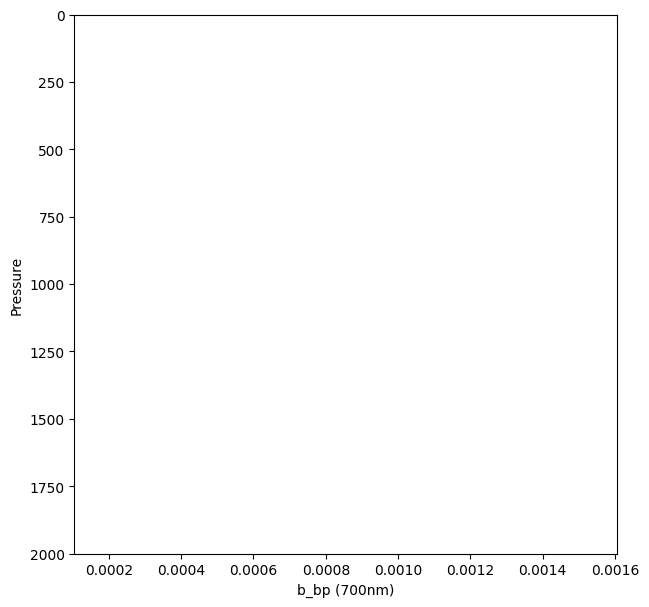

In [51]:
iprof = -2
#
fig = plt.figure(figsize=(7,7))
ax = plt.gca()
#
ax.plot(ds.b_bp700.data[iprof,:], ds.Pressure.data[iprof,:]) 
#
ax.set_ylim(2000.,0)
#
ax.set_xlabel('b_bp (700nm)')
ax.set_ylabel('Pressure')
#
plt.show()

In [48]:
ds.b_bp700[13]

<xarray.DataArray 'b_bp700' (N_LEVELS: 1585)> Size: 13kB
array([nan, nan, nan, ..., nan, nan, nan], shape=(1585,))
Dimensions without coordinates: N_LEVELS
Attributes:
    units:    1/m

In [46]:
has_value = np.isfinite(ds.b_bp700.data[:,-100:])
np.any(has_value, axis=1)

array([False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True])

In [50]:
ds.b_bp700.data[-2,-100:]

array([     nan, 0.000658,      nan,      nan, 0.000632,      nan,
            nan, 0.000629,      nan,      nan, 0.000662,      nan,
            nan, 0.000645,      nan,      nan, 0.000674,      nan,
            nan, 0.000677,      nan,      nan, 0.000601,      nan,
            nan, 0.000641,      nan,      nan, 0.00063 ,      nan,
            nan, 0.00064 ,      nan,      nan, 0.000641,      nan,
            nan, 0.000652,      nan,      nan, 0.000642,      nan,
            nan, 0.000641,      nan,      nan, 0.00063 ,      nan,
            nan, 0.000629,      nan,      nan, 0.000674,      nan,
            nan, 0.000611,      nan,      nan, 0.000681,      nan,
            nan, 0.000624,      nan,      nan, 0.00065 ,      nan,
            nan, 0.000653,      nan,      nan, 0.000621,      nan,
            nan, 0.000628,      nan,      nan,      nan, 0.000594,
            nan,      nan,      nan, 0.000659,      nan,      nan,
            nan, 0.000687,      nan,      nan,      nan, 0.000

In [45]:
ds.Pressure.data[-2,-100:]

array([59.96, 59.76, 58.84, 58.  , 57.76, 56.84, 55.92, 55.76, 54.76,
       54.  , 53.72, 52.84, 52.04, 51.84, 50.8 , 50.  , 49.8 , 48.72,
       47.96, 47.64, 46.88, 45.96, 45.8 , 44.72, 43.96, 43.68, 42.76,
       42.  , 41.72, 40.8 , 40.  , 39.84, 38.88, 38.04, 37.84, 36.88,
       36.04, 35.8 , 34.8 , 34.  , 33.76, 32.84, 32.04, 31.76, 30.8 ,
       30.04, 29.84, 28.84, 28.  , 27.76, 26.76, 25.96, 25.72, 24.68,
       24.  , 23.64, 22.84, 22.08, 21.84, 20.84, 20.  , 19.76, 18.68,
       17.96, 17.76, 16.68, 15.96, 15.6 , 14.72, 14.  , 13.68, 12.84,
       12.  , 11.8 , 10.72, 10.6 ,  9.96,  9.6 ,  9.  ,  8.84,  8.04,
        7.8 ,  7.04,  6.76,  6.  ,  5.68,  5.  ,  4.76,  4.04,  3.88,
        3.04,  2.72,  2.04,  1.64,  1.04,  1.  ,  0.88,  0.76,  0.68,
        0.56])

In [49]:
ds

<xarray.Dataset> Size: 8MB
Dimensions:              (N_PROF: 14, N_LEVELS: 1585, NPARAMETER: 53)
Dimensions without coordinates: N_PROF, N_LEVELS, NPARAMETER
Data variables: (12/76)
    Cruise               |S11 11B ...
    Station              (N_PROF) int32 56B ...
    Lon                  (N_PROF) float64 112B ...
    Lat                  (N_PROF) float64 112B ...
    Lat_QF               (N_PROF) |S1 14B ...
    Lat_QFA              (N_PROF) float64 112B ...
    ...                   ...
    Type                 |S1 1B ...
    mon_day_yr           (N_PROF) |S10 140B ...
    hh_mm                (N_PROF) |S5 70B ...
    Parameters           (NPARAMETER) |S19 1kB ...
    JULD                 (N_PROF) datetime64[ns] 112B ...
    REFERENCE_DATE_TIME  object 8B ...
Attributes:
    Comments:  \n//0\n//<Encoding>UTF-8</Encoding>\n//File updated on 06/24/2...